In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.cluster import KMeans
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
random_seed = 123

Using device: cpu


In [57]:
# Load Dataset
data = './early_2012_2013_loan_sample_with_outcome.csv'
df = pd.read_csv(data)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           50000 non-null  int64  
 1   member_id                    50000 non-null  int64  
 2   loan_amnt                    50000 non-null  int64  
 3   funded_amnt                  50000 non-null  int64  
 4   funded_amnt_inv              50000 non-null  float64
 5   term                         50000 non-null  float64
 6   int_rate                     50000 non-null  float64
 7   installment                  50000 non-null  float64
 8   grade                        50000 non-null  str    
 9   sub_grade                    50000 non-null  str    
 10  emp_title                    47168 non-null  str    
 11  emp_length                   48198 non-null  float64
 12  home_ownership               50000 non-null  str    
 13  annual_inc                 

In [58]:
# Data Cleaning
# Check missing values
missing_counts = df.isna().sum()
print("\nMissing values per column:")
print(missing_counts)
# Note: 3 columns (tot_coll_amt, tot_cur_bal, total_credit_rv) share 14,618 missing values. Other blanks are acceptable given feature definitions.
# Check if all 3 columns' missing values occur in the same rows
co_missing = df[["tot_coll_amt", "tot_cur_bal", "total_credit_rv"]].isna().all(axis=1).sum()
print(f"\nRows where tot_coll_amt, tot_cur_bal AND total_credit_rv are all NA: {co_missing}")
# All missing values in the 3 features are contained in the same records.

# Data encoding & coversions
# Remove "%" from revol_util and convert to numeric
df["revol_util"] = np.array([
    float(str(x).replace("%", "")) if str(x).replace("%","").replace('.','',1).isdigit()
    else np.nan
    for x in df["revol_util"]])

# Convert loan_is_bad from boolean to 1/0 integer NumPy array
df["loan_is_bad"] = df["loan_is_bad"].astype(int)

# Create ordinal grade variable: A=1, B=2, ..., G=7
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
df["grade_ord"] = df["grade"].map({g: i + 1 for i, g in enumerate(grade_order)})

# Convert all remaining object/string columns to 'category' dtype
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")


Missing values per column:
id                                 0
member_id                          0
loan_amnt                          0
funded_amnt                        0
funded_amnt_inv                    0
term                               0
int_rate                           0
installment                        0
grade                              0
sub_grade                          0
emp_title                       2832
emp_length                      1802
home_ownership                     0
annual_inc                         0
verification_status                0
issue_d                            0
loan_status                        0
pymnt_plan                         0
desc                           18996
purpose                            0
title                              2
zip_code                           0
addr_state                         0
dti                                0
delinq_2yrs                        0
earliest_cr_line                   0
inq_last_6

C:\Users\kathe\AppData\Local\Temp\ipykernel_39440\2822971570.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [59]:
# Selection & Further Data Prep
# Only information available at the loan decision point is included, same as the ones used for clustering
select = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "revol_util",
    "total_acc",
    "loan_is_bad"
]

df_select = df[select].copy()

# Checking data post selection
missing_counts_select = df_select.isna().sum()
print(missing_counts_select)

# Dropping NAs
df_select = df_select.dropna()

# Check data structure prep
print("\nData structure after data prep:")
df_select.info()

loan_amnt          0
int_rate           0
annual_inc         0
dti                0
delinq_2yrs        0
inq_last_6mths     0
revol_util        31
total_acc          0
loan_is_bad        0
dtype: int64

Data structure after data prep:
<class 'pandas.DataFrame'>
Index: 49969 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loan_amnt       49969 non-null  int64  
 1   int_rate        49969 non-null  float64
 2   annual_inc      49969 non-null  float64
 3   dti             49969 non-null  float64
 4   delinq_2yrs     49969 non-null  int64  
 5   inq_last_6mths  49969 non-null  int64  
 6   revol_util      49969 non-null  float64
 7   total_acc       49969 non-null  int64  
 8   loan_is_bad     49969 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 3.8 MB


In [60]:
# Data Partitioning
X = df_select.drop("loan_is_bad", axis = 1) # independent features
y = df_select["loan_is_bad"] # target

# Split 1: Separate Test set (15%) from the rest (85%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=random_seed, stratify=y)

# Split 2: Separate Train (70% of total) and Validation (15% of total)
# 0.15 / 0.85 approx 0.176
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=random_seed, stratify=y_temp)

# Scale the data (fit only on training data to prevent data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [61]:
# Data Balancing
# Checking for data imbalance in target
print(y.value_counts())
print("\nProportions:")
print(y.value_counts(normalize=True))
value_counts = y.value_counts()
imbalance_ratio = value_counts.min() / value_counts.max()
print(f"\nImbalance ratio in target: {imbalance_ratio:.4f}")

# Using undersampling to address the class imbalance
target_ratio = 0.67  # minority/majority

rus = RandomUnderSampler(sampling_strategy=target_ratio, random_state=random_seed)

X_undersampled, y_undersampled = rus.fit_resample(X_train, y_train)

print(f"\n--- Results from the Undersampled Training Set ---")
print(f"Original Training Size: {len(y_train)}")
print(f"New Undersampled Training Size: {len(y_undersampled)}")
print("\nCounts in Undersampled Data:")
print(y_undersampled.value_counts())
print("\nProportion in Undersampled Data:")
print(y_undersampled.value_counts(normalize=True))

loan_is_bad
0    42161
1     7808
Name: count, dtype: int64

Proportions:
loan_is_bad
0    0.843743
1    0.156257
Name: proportion, dtype: float64

Imbalance ratio in target: 0.1852

--- Results from the Undersampled Training Set ---
Original Training Size: 34980
New Undersampled Training Size: 13624

Counts in Undersampled Data:
loan_is_bad
0    8158
1    5466
Name: count, dtype: int64

Proportion in Undersampled Data:
loan_is_bad
0    0.598796
1    0.401204
Name: proportion, dtype: float64


In [62]:
# Convert to PyTorch Tensors
X_train_t = torch.FloatTensor(X_undersampled)
y_train_t = torch.LongTensor(y_undersampled.to_numpy())
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val.to_numpy())
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test.to_numpy())

In [63]:
# Create DataLoaders
# Checking number of entries in each set
print(f"Training samples: {len(X_undersampled)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")
print(X_undersampled.shape, y_undersampled.shape)
print(X_test.shape, y_test.shape)

batch_size = 256
generator = torch.Generator()
generator.manual_seed(random_seed)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, generator=generator)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

Training samples: 13624, Validation samples: 7493, Test samples: 7496
(13624, 8) (13624,)
(7496, 8) (7496,)


In [64]:
# Define the Model
# Setting random state to allow reproducibility of results
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class LoansModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LoansModel, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Output Layer
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [65]:
# Initialize the model, loss function, and optimizer
model = LoansModel(input_dim=X_train.shape[1], num_classes=2).to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# AdamW adds weight decay directly to the update rule for better regularization
optimizer = optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-2)

# Learning Rate Decay: Reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [66]:
# Define training loop
epochs = 100
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

train_losses, val_losses = [], []

for epoch in range(epochs):
    if early_stop:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t.to(device))
        epoch_val_loss = criterion(val_outputs, y_val_t.to(device)).item()
       
        _, val_preds_t = torch.max(val_outputs, dim=1)
        val_preds = val_preds_t.cpu().numpy()
        val_labels = y_val_t.numpy()

    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)

    # --- Early Stopping Logic ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stop = True

# every 5 steps we will print out the current loss
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")


Epoch 005/100 | Train Loss: 0.6282 | Val Loss: 0.5640
Epoch 010/100 | Train Loss: 0.6253 | Val Loss: 0.5480
Early stopping triggered at epoch 13



Metrics for model evaluation:
Accuracy: 0.7760
Precision: 0.2740
Recall (Sensitivity): 0.2630
F1-Score: 0.2684

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      6325
           1       0.27      0.26      0.27      1171

    accuracy                           0.78      7496
   macro avg       0.57      0.57      0.57      7496
weighted avg       0.77      0.78      0.77      7496


Important loan metrics:
Approval Rate: 0.8501
Default Rate (Approved):0.1354
False Negative Rate: 0.7370
Loss: 863.0000


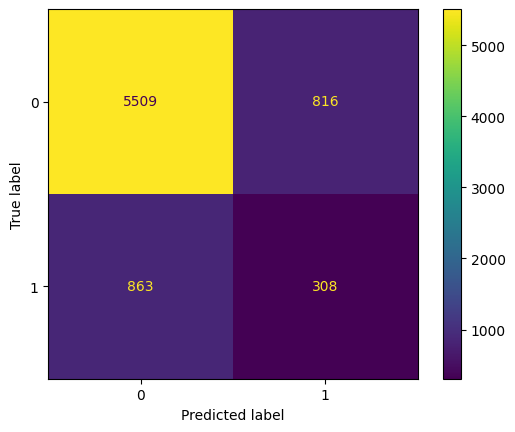

In [67]:
# Model Evaluation (Confusion Matrix & Important Metrics)
# Load the best model weights found during training
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # Collect predictions and true labels for confusion matrix
        all_preds.extend(predicted.cpu().numpy()) # predictions
        all_labels.extend(labels.cpu().numpy()) # actual

# Calculate specific metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"\nMetrics for model evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["0", "1"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

# Custom credit / loan metrics
approval_rate = (fn + tn) / (tp + fp + tn + fn)
default_rate_approved = fn / (tn + fn) if (tn + fn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nImportant loan metrics:")
print(f"Approval Rate: {approval_rate:.4f}")
print(f"Default Rate (Approved):{default_rate_approved:.4f}")
print(f"False Negative Rate: {fnr:.4f}")
print(f"Loss: {fn:.4f}")

# Display confusion matrix
cm_display = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
cm_display.plot()
plt.show()

Test Loss: 0.5118
Test Accuracy: 77.60%


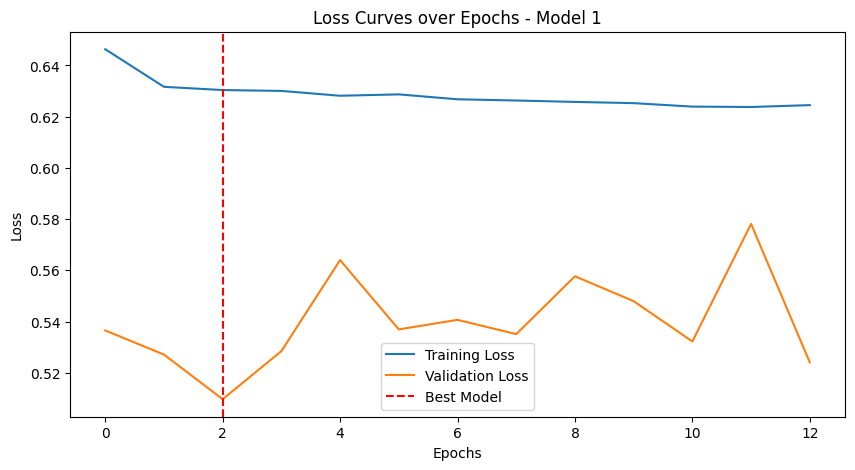

In [68]:
# Loss Curves

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss / len(test_loader.dataset):.4f}")
print(f"Test Accuracy: {(100 * correct / total):.2f}%")

# Plotting the learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(x=len(train_losses) - epochs_no_improve - 1, color='r', linestyle='--', label='Best Model')
plt.title('Loss Curves over Epochs - Model 1')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [69]:
# Trying alternative way of handling imbalance by using class weights in the loss function instead of undersampling

# Convert original training data to PyTorch Tensors
X_train_t2 = torch.FloatTensor(X_train)
y_train_t2 = torch.LongTensor(y_train.to_numpy())

In [70]:
# Defining Model with Same Architecture but with Original Data (No Undersampling) and Class Weights in Loss Function
# Reset all random seeds so new model starts from same state as previous model did
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
np.random.seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class LoansModel2(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LoansModel2, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Output Layer
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [71]:
# Initialize the New Model, Loss Function (including class weights), and Optimizer
model2 = LoansModel2(input_dim=X_train.shape[1], num_classes=2).to(device)

# Calculate class weights
class_weights = torch.FloatTensor([1.0, (1/imbalance_ratio)]).to(device)
criterion2 = nn.CrossEntropyLoss(weight=class_weights)

# AdamW adds weight decay directly to the weight update rule for better regularization
optimizer2 = optim.AdamW(model2.parameters(), lr=0.003, weight_decay=1e-2)

# Learning Rate Decay: Reduces LR when validation loss plateaus
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='min', factor=0.5, patience=10)

# Separating the data loader for model2 with its own generator
generator2 = torch.Generator()
generator2.manual_seed(random_seed)
train_loader2 = DataLoader(TensorDataset(X_train_t2, y_train_t2), batch_size=batch_size, shuffle=True, generator=generator2)

In [72]:
# Re-defining the Training Loop
epochs2 = 100
patience2 = 10
best_val_loss2 = float('inf')
epochs_no_improve2 = 0
early_stop2 = False

train_losses2, val_losses2 = [], []

for epoch in range(epochs2):
    if early_stop2:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model2.train()
    running_loss2 = 0.0
    for inputs, labels in train_loader2:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer2.zero_grad()
        outputs = model2(inputs)
        loss = criterion2(outputs, labels)
        loss.backward()
        optimizer2.step()

        running_loss2 += loss.item() * inputs.size(0)

    epoch_train_loss2 = running_loss2 / len(train_loader2.dataset)
    train_losses2.append(epoch_train_loss2)

    # --- Validation Phase ---
    model2.eval()
    with torch.no_grad():
        val_outputs2 = model2(X_val_t.to(device))
        epoch_val_loss2 = criterion2(val_outputs2, y_val_t.to(device)).item()
        
        _, val_preds_t2 = torch.max(val_outputs2, dim=1)
        val_preds2 = val_preds_t2.cpu().numpy()
        val_labels2 = y_val_t.numpy()

    val_losses2.append(epoch_val_loss2)

    scheduler2.step(epoch_val_loss2)

    # --- Early Stopping Logic ---
    if epoch_val_loss2 < best_val_loss2:
        best_val_loss2 = epoch_val_loss2
        epochs_no_improve2 = 0
        # new best model save file
        torch.save(model2.state_dict(), 'best_model2.pth')
    else:
        epochs_no_improve2 += 1
        if epochs_no_improve2 >= patience2:
            early_stop2 = True

# every 5 steps we will print out the current loss
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs2} | Train Loss: {epoch_train_loss2:.4f} | Val Loss: {epoch_val_loss2:.4f}")

Epoch 005/100 | Train Loss: 0.6500 | Val Loss: 0.6511
Epoch 010/100 | Train Loss: 0.6464 | Val Loss: 0.6527
Early stopping triggered at epoch 13



Metrics for model2 evaluation:
Accuracy: 0.5994
Precision: 0.2236
Recall (Sensitivity): 0.6328
F1-Score: 0.3304

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.59      0.71      6325
           1       0.22      0.63      0.33      1171

    accuracy                           0.60      7496
   macro avg       0.56      0.61      0.52      7496
weighted avg       0.79      0.60      0.65      7496


Important loan metrics:
Approval Rate: 0.5579
Default Rate (Approved): 0.1028
False Negative Rate: 0.3672
Loss: 430.0000


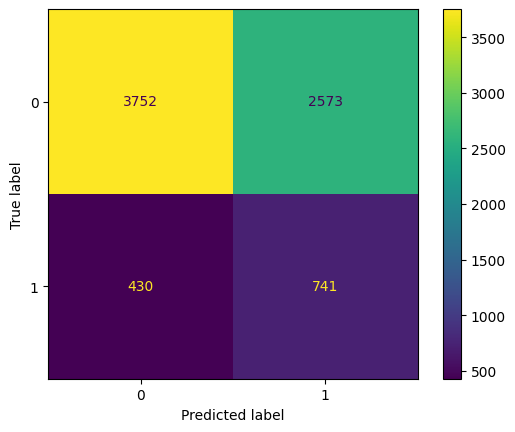

In [73]:
# Model Evaluation for New Model (Confusion Matrix & Important Metrics)
# Load the best model weights found during training
model2.load_state_dict(torch.load('best_model2.pth'))
model2.eval()

all_preds2 = []
all_labels2 = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model2(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # Collect predictions and true labels for confusion matrix
        all_preds2.extend(predicted.cpu().numpy()) # predictions
        all_labels2.extend(labels.cpu().numpy()) # actuals

# Calculate specific metrics
accuracy2 = accuracy_score(all_labels2, all_preds2)
precision2 = precision_score(all_labels2, all_preds2)
recall2 = recall_score(all_labels2, all_preds2)
f1_2 = f1_score(all_labels2, all_preds2)

print(f"\nMetrics for model2 evaluation:")
print(f"Accuracy: {accuracy2:.4f}")
print(f"Precision: {precision2:.4f}")
print(f"Recall (Sensitivity): {recall2:.4f}")
print(f"F1-Score: {f1_2:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels2, all_preds2, target_names=["0", "1"]))

# Confusion matrix
cm2 = confusion_matrix(all_labels2, all_preds2)
tn2, fp2, fn2, tp2 = cm2.ravel()

# Custom credit / loan metrics
approval_rate2 = (fn2 + tn2) / (tp2 + fp2 + tn2 + fn2)
default_rate_approved2 = fn2 / (tn2 + fn2) if (tn2 + fn2) > 0 else 0
fnr2 = fn2 / (fn2 + tp2) if (fn2 + tp2) > 0 else 0

print(f"\nImportant loan metrics:")
print(f"Approval Rate: {approval_rate2:.4f}")
print(f"Default Rate (Approved): {default_rate_approved2:.4f}")
print(f"False Negative Rate: {fnr2:.4f}")
print(f"Loss: {fn2:.4f}")

# Display confusion matrix
cm_display2 = ConfusionMatrixDisplay(cm2, display_labels=[0, 1])
cm_display2.plot()
plt.show()

Test Loss: 0.6540
Test Accuracy: 59.94%


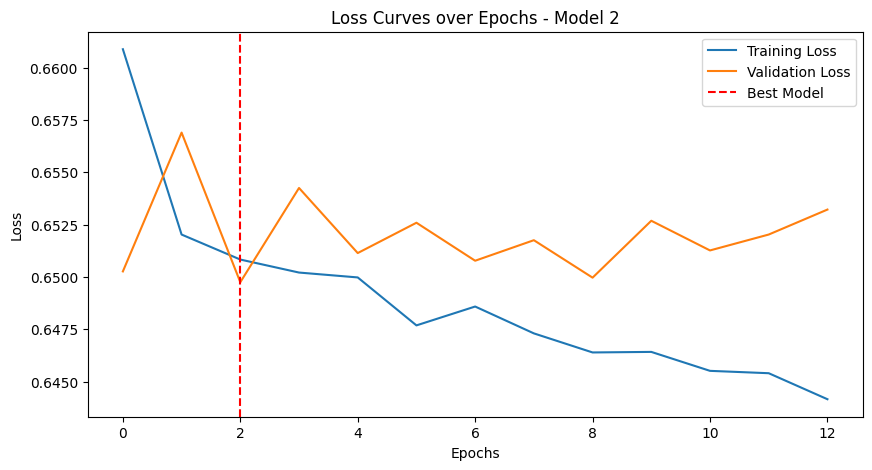

In [74]:
# Loss Curves for Model 2

correct2 = 0
total2 = 0
test_loss2 = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model2(inputs)
        loss = criterion2(outputs, labels)
        test_loss2 += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total2 += labels.size(0)
        correct2 += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss2 / len(test_loader.dataset):.4f}")
print(f"Test Accuracy: {(100 * correct2 / total2):.2f}%")

# Plotting the learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses2, label='Training Loss')
plt.plot(val_losses2, label='Validation Loss')
plt.axvline(x=len(train_losses2) - epochs_no_improve2 - 1, color='r', linestyle='--', label='Best Model')
plt.title('Loss Curves over Epochs - Model 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [75]:
# Same architecture and class weights as Model 2, but with a reduced learning rate (0.003 → 0.001) to test whether slower, more careful updates improve convergence.
# Re-define the Model
# Reset all random seeds so new model starts from same state as previous model did
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
np.random.seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class LoansModel3(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LoansModel3, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Output Layer
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [76]:
# Re-initialize the model, loss function, and optimizer for a 3rd time
model3 = LoansModel3(input_dim=X_train.shape[1], num_classes=2).to(device)

# Loss function including class weights
criterion3 = nn.CrossEntropyLoss(weight=class_weights)

# Learning rate decreased from 0.003 to 0.001
optimizer3 = optim.AdamW(model3.parameters(), lr=0.001, weight_decay=1e-2)

# Learning Rate Decay: Reduces LR when validation loss plateaus
scheduler3 = optim.lr_scheduler.ReduceLROnPlateau(optimizer3, mode='min', factor=0.5, patience=10)

# Separating the data loader for model3 with its own generator
generator3 = torch.Generator()
generator3.manual_seed(random_seed)
train_loader3 = DataLoader(TensorDataset(X_train_t2, y_train_t2), batch_size=batch_size, shuffle=True, generator=generator3)

In [77]:
# Re-define training loop for a 3rd time
epochs3 = 100
patience3 = 10
best_val_loss3 = float('inf')
epochs_no_improve3 = 0
early_stop3 = False

train_losses3, val_losses3 = [], []

for epoch in range(epochs3):
    if early_stop3:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model3.train()
    running_loss3 = 0.0
    for inputs, labels in train_loader3:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer3.zero_grad()
        outputs = model3(inputs)
        loss = criterion3(outputs, labels)
        loss.backward()
        optimizer3.step()

        running_loss3 += loss.item() * inputs.size(0)

    epoch_train_loss3 = running_loss3 / len(train_loader3.dataset)
    train_losses3.append(epoch_train_loss3)

    # --- Validation Phase ---
    model3.eval()
    with torch.no_grad():
        val_outputs3 = model3(X_val_t.to(device))
        epoch_val_loss3 = criterion3(val_outputs3, y_val_t.to(device)).item()
       
        _, val_preds_t3 = torch.max(val_outputs3, dim=1)
        val_preds3 = val_preds_t3.cpu().numpy()
        val_labels3 = y_val_t.numpy()

    val_losses3.append(epoch_val_loss3)

    scheduler3.step(epoch_val_loss3)

    # --- Early Stopping Logic ---
    if epoch_val_loss3 < best_val_loss3:
        best_val_loss3 = epoch_val_loss3
        epochs_no_improve3 = 0
        # Save the best model
        torch.save(model3.state_dict(), 'best_model3.pth')
    else:
        epochs_no_improve3 += 1
        if epochs_no_improve3 >= patience3:
            early_stop3 = True

# every 5 steps we will print out the current loss
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs3} | Train Loss: {epoch_train_loss3:.4f} | Val Loss: {epoch_val_loss3:.4f}")

Epoch 005/100 | Train Loss: 0.6480 | Val Loss: 0.6523
Epoch 010/100 | Train Loss: 0.6443 | Val Loss: 0.6518
Epoch 015/100 | Train Loss: 0.6419 | Val Loss: 0.6544
Early stopping triggered at epoch 19



Metrics for model3 evaluation:
Accuracy: 0.5858
Precision: 0.2189
Recall (Sensitivity): 0.6430
F1-Score: 0.3266

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.58      0.70      6325
           1       0.22      0.64      0.33      1171

    accuracy                           0.59      7496
   macro avg       0.56      0.61      0.51      7496
weighted avg       0.79      0.59      0.64      7496


Important loan metrics:
Approval Rate: 0.5411
Default Rate (Approved): 0.1031
False Negative Rate: 0.3570
Loss: 418.0000


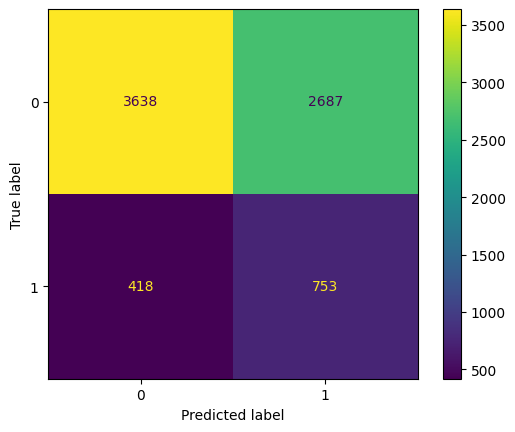

In [78]:
# Model Evaluation for New Model (Confusion Matrix & Important Metrics)
# Load the best model weights found during training
model3.load_state_dict(torch.load('best_model3.pth'))
model3.eval()

all_preds3 = []
all_labels3 = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model3(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # Collect predictions and true labels for confusion matrix
        all_preds3.extend(predicted.cpu().numpy()) # predictions
        all_labels3.extend(labels.cpu().numpy()) # actuals

# Calculate specific metrics
accuracy3 = accuracy_score(all_labels3, all_preds3)
precision3 = precision_score(all_labels3, all_preds3)
recall3 = recall_score(all_labels3, all_preds3)
f1_3 = f1_score(all_labels3, all_preds3)

print(f"\nMetrics for model3 evaluation:")
print(f"Accuracy: {accuracy3:.4f}")
print(f"Precision: {precision3:.4f}")
print(f"Recall (Sensitivity): {recall3:.4f}")
print(f"F1-Score: {f1_3:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels3, all_preds3, target_names=["0", "1"]))

# Confusion matrix
cm3 = confusion_matrix(all_labels3, all_preds3)
tn3, fp3, fn3, tp3 = cm3.ravel()

# Custom credit / loan metrics
approval_rate3 = (fn3 + tn3) / (tp3 + fp3 + tn3 + fn3)
default_rate_approved3 = fn3 / (tn3 + fn3) if (tn3 + fn3) > 0 else 0
fnr3 = fn3 / (fn3 + tp3) if (fn3 + tp3) > 0 else 0

print(f"\nImportant loan metrics:")
print(f"Approval Rate: {approval_rate3:.4f}")
print(f"Default Rate (Approved): {default_rate_approved3:.4f}")
print(f"False Negative Rate: {fnr3:.4f}")
print(f"Loss: {fn3:.4f}")

# Display confusion matrix
cm_display3 = ConfusionMatrixDisplay(cm3, display_labels=[0, 1])
cm_display3.plot()
plt.show()

Test Loss: 0.6557
Test Accuracy: 58.58%


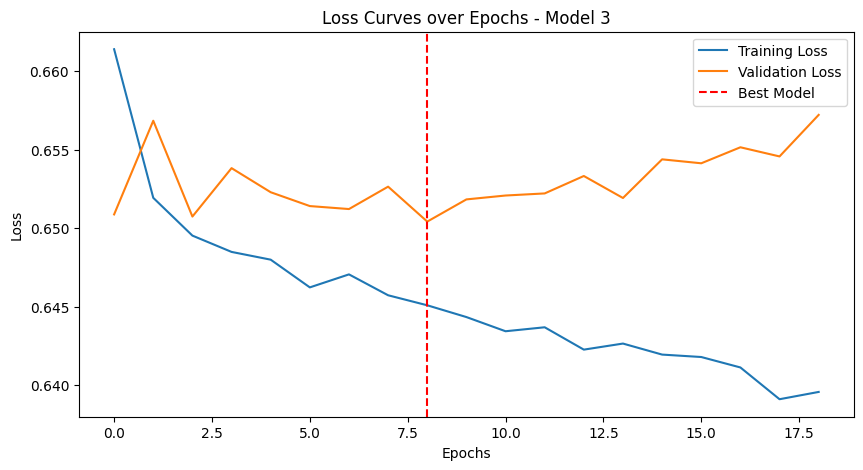

In [79]:
# Loss Curves for Model 3

correct3 = 0
total3 = 0
test_loss3 = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model3(inputs)
        loss = criterion3(outputs, labels)
        test_loss3 += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total3 += labels.size(0)
        correct3 += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss3 / len(test_loader.dataset):.4f}")
print(f"Test Accuracy: {(100 * correct3 / total3):.2f}%")

# Plotting the learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses3, label='Training Loss')
plt.plot(val_losses3, label='Validation Loss')
plt.axvline(x=len(train_losses3) - epochs_no_improve3 - 1, color='r', linestyle='--', label='Best Model')
plt.title('Loss Curves over Epochs - Model 3')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [80]:
# Model Comparison Table
# Find the epoch at which each model achieved its best validation loss & respective training and validation losses
best_epoch_1 = len(train_losses)  - epochs_no_improve  - 1  # 0-indexed → +1 for display
best_epoch_2 = len(train_losses2) - epochs_no_improve2 - 1
best_epoch_3 = len(train_losses3) - epochs_no_improve3 - 1

# Model 1
best_train_loss_1 = train_losses[best_epoch_1]
best_val_loss_1   = val_losses[best_epoch_1]

# Model 2
best_train_loss_2 = train_losses2[best_epoch_2]
best_val_loss_2   = val_losses2[best_epoch_2]

# Model 3
best_train_loss_3 = train_losses3[best_epoch_3]
best_val_loss_3   = val_losses3[best_epoch_3]

# Compile evaluation metrics into dataframe for comparison
comparison_data = {
    "Metric": [
        "Training Loss",
        "Validation Loss",
        "Accuracy",
        "Precision",
        "Recall (Sensitivity)",
        "F1-Score",
        "Approval Rate",
        "Default Rate (Approved)",
        "False Negative Rate",
        "Loss (False Negatives)",
    ],
    "Model 1\n(Undersampling, LR=0.003)": [        
        round(best_train_loss_1, 4),
        round(best_val_loss_1,   4),
        round(accuracy,          4),
        round(precision,         4),
        round(recall,            4),
        round(f1,                4),
        round(approval_rate,     4),
        round(default_rate_approved, 4),
        round(fnr,               4),
        int(fn),
    ],
    "Model 2\n(Class Weights, LR=0.003)": [
        round(best_train_loss_2, 4),
        round(best_val_loss_2,   4),
        round(accuracy2,         4),
        round(precision2,        4),
        round(recall2,           4),
        round(f1_2,              4),
        round(approval_rate2,    4),
        round(default_rate_approved2, 4),
        round(fnr2,              4),
        int(fn2),
    ],
    "Model 3\n(Class Weights, LR=0.001)": [
        round(best_train_loss_3, 4),
        round(best_val_loss_3,   4),
        round(accuracy3,         4),
        round(precision3,        4),
        round(recall3,           4),
        round(f1_3,              4),
        round(approval_rate3,    4),
        round(default_rate_approved3, 4),
        round(fnr3,              4),
        int(fn3),
    ],
}
 
df_comparison = pd.DataFrame(comparison_data).set_index("Metric")

format_dict = {}
for col in df_comparison.columns:
    def make_formatter(c):
        def fmt(x):
            if df_comparison.index[df_comparison[c] == x][0] in ["Loss (False Negatives)"]:
                return f"{int(x)}"
            return f"{x:.4f}"
        return fmt
    format_dict[col] = make_formatter(col)

# Display the comparison table
table_str = df_comparison.to_string(formatters=format_dict)
table_width = len(table_str.splitlines()[0])
title = "Figure12: Deep Learning Model Comparison for Loan Default Prediction"

print("=" * table_width)
print(title.center(table_width))
print("=" * table_width)
print(table_str)
print("=" * table_width)

                              Figure12: Deep Learning Model Comparison for Loan Default Prediction                              
                        Model 1\n(Undersampling, LR=0.003) Model 2\n(Class Weights, LR=0.003) Model 3\n(Class Weights, LR=0.001)
Metric                                                                                                                          
Training Loss                                       0.6304                             0.6508                             0.6451
Validation Loss                                     0.5096                             0.6497                             0.6504
Accuracy                                            0.7760                             0.5994                             0.5858
Precision                                           0.2740                             0.2236                             0.2189
Recall (Sensitivity)                                0.2630                             0.6328    

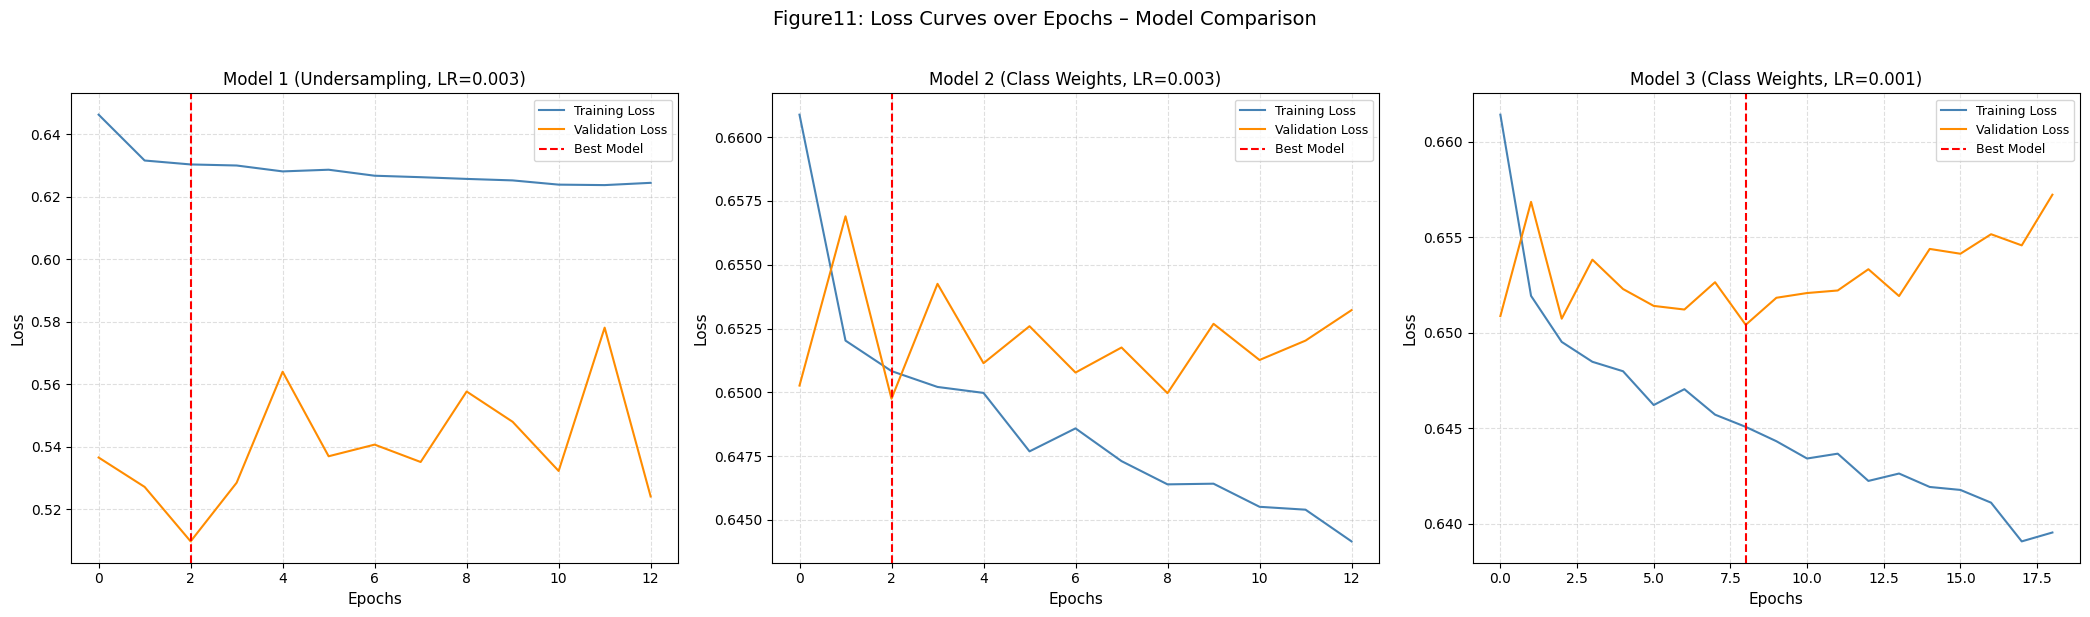

In [81]:
# Comparing all loss curves in a single plot

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)

models = [
    {
        "train_losses": train_losses,
        "val_losses":   val_losses,
        "epochs_no_improve": epochs_no_improve,
        "title": "Model 1 (Undersampling, LR=0.003)",
    },
    {
        "train_losses": train_losses2,
        "val_losses":   val_losses2,
        "epochs_no_improve": epochs_no_improve2,
        "title": "Model 2 (Class Weights, LR=0.003)",
    },
    {
        "train_losses": train_losses3,
        "val_losses":   val_losses3,
        "epochs_no_improve": epochs_no_improve3,
        "title": "Model 3 (Class Weights, LR=0.001)",
    },
]

for ax, m in zip(axes, models):
    best_epoch = len(m["train_losses"]) - m["epochs_no_improve"] - 1

    ax.plot(m["train_losses"], label="Training Loss",   color="steelblue")
    ax.plot(m["val_losses"],   label="Validation Loss", color="darkorange")
    ax.axvline(x=best_epoch,   color="red", linestyle="--", label="Best Model")

    ax.set_title(m["title"], fontsize=12)
    ax.set_xlabel("Epochs", fontsize=11)
    ax.set_ylabel("Loss",   fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Figure11: Loss Curves over Epochs – Model Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [82]:
# Use Model 3 and Evaluate Performance Based on Clusters
# Remove outliers using Mahalanobis distance (replicating Q2 R code)
df_cluster = df_select.drop("loan_is_bad", axis=1)

cov_matrix = np.cov(df_cluster.values, rowvar=False)
cov_inv    = np.linalg.inv(cov_matrix)
mean_vec   = df_cluster.mean().values

maha_dist   = df_cluster.apply(
    lambda row: mahalanobis(row.values, mean_vec, cov_inv), axis=1
)
maha_pvalue = chi2.sf(maha_dist ** 2, df=len(df_cluster.columns))
df_cluster_clean = df_cluster[maha_pvalue >= 0.001]

# Scale after outlier removal and fit k-means
cluster_scaler    = StandardScaler()
df_cluster_scaled = cluster_scaler.fit_transform(df_cluster_clean)

kmeans = KMeans(n_clusters=4, init="k-means++", n_init=25, random_state=123)
df_select_cluster = df_select.loc[df_cluster_clean.index].copy()
df_select_cluster["cluster"] = kmeans.fit_predict(df_cluster_scaled)

# Map cluster numbers to Q2 labels
centres = pd.DataFrame(
    cluster_scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df_cluster_clean.columns
)

label_map = {
    centres["delinq_2yrs"].idxmax(): "Cluster 1 (High Risk)",
    centres["dti"].idxmin():         "Cluster 2 (Low Risk)",
    centres["revol_util"].idxmax():  "Cluster 3 (Stretched)",
    centres["loan_amnt"].idxmax():   "Cluster 4 (High Exposure)",
}
df_select_cluster["cluster_label"] = df_select_cluster["cluster"].map(label_map)

# Recover original test indices from the Q3 split (Cell 4)
_, original_test_idx, _, _ = train_test_split(
    df_select_cluster.index, df_select_cluster["loan_is_bad"],
    test_size=0.15, random_state=random_seed,
    stratify=df_select_cluster["loan_is_bad"]
)

# Align predictions with cleaned dataset
# Find test observations that survived outlier removal
clean_idx  = df_cluster_clean.index
shared_idx = [i for i, idx in enumerate(original_test_idx) if idx in clean_idx]

all_preds3_cluster  = np.array(all_preds3)[shared_idx]
all_labels3_cluster = np.array(all_labels3)[shared_idx]

test_cluster_labels = df_select_cluster.loc[
    [original_test_idx[i] for i in shared_idx], "cluster_label"
].values

# Compute per-cluster metrics
cluster_results = []

for label in sorted(set(test_cluster_labels)):
    mask   = test_cluster_labels == label
    preds  = all_preds3_cluster[mask]
    labels = all_labels3_cluster[mask]

    cm_c = confusion_matrix(labels, preds)
    tn_c, fp_c, fn_c, tp_c = cm_c.ravel()

    total       = len(labels)
    accuracy_c  = accuracy_score(labels, preds)
    precision_c = precision_score(labels, preds, zero_division=0)
    recall_c    = recall_score(labels, preds, zero_division=0)
    f1_c        = f1_score(labels, preds, zero_division=0)
    approval_c  = (fn_c + tn_c) / total
    default_c   = fn_c / (tn_c + fn_c) if (tn_c + fn_c) > 0 else 0
    fnr_c       = fn_c / (fn_c + tp_c) if (fn_c + tp_c) > 0 else 0

    cluster_results.append({
        "Cluster":                 label,
        "N (Test)":                total,
        "Accuracy":                round(accuracy_c,  4),
        "Precision":               round(precision_c, 4),
        "Recall (Sensitivity)":    round(recall_c,    4),
        "F1-Score":                round(f1_c,        4),
        "Approval Rate":           round(approval_c,  4),
        "Default Rate (Approved)": round(default_c,   4),
        "False Negative Rate":     round(fnr_c,       4),
        "Loss (False Negatives)":  int(fn_c),
    })

df_cluster_results = pd.DataFrame(cluster_results).set_index("Cluster")

# Display the cluster performance table
table_str   = df_cluster_results.to_string()
table_width = len(table_str.splitlines()[0])
title       = "Figure13: Model 3 Performance by Borrower Cluster"

print("=" * table_width)
print(title.center(table_width))
print("=" * table_width)
print(table_str)
print("=" * table_width)

                                                              Figure13: Model 3 Performance by Borrower Cluster                                                              
                           N (Test)  Accuracy  Precision  Recall (Sensitivity)  F1-Score  Approval Rate  Default Rate (Approved)  False Negative Rate  Loss (False Negatives)
Cluster                                                                                                                                                                      
Cluster 1 (High Risk)           922    0.5770     0.1986                0.6014    0.2986         0.5466                   0.1091               0.3986                      55
Cluster 2 (Low Risk)           1821    0.5969     0.2239                0.7052    0.3399         0.5365                   0.0809               0.2948                      79
Cluster 3 (Stretched)          3011    0.5865     0.2244                0.6253    0.3303         0.5457                   0.1120  